# **Simple Linear Regression**

In [4]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('height-weight.csv')

In [3]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


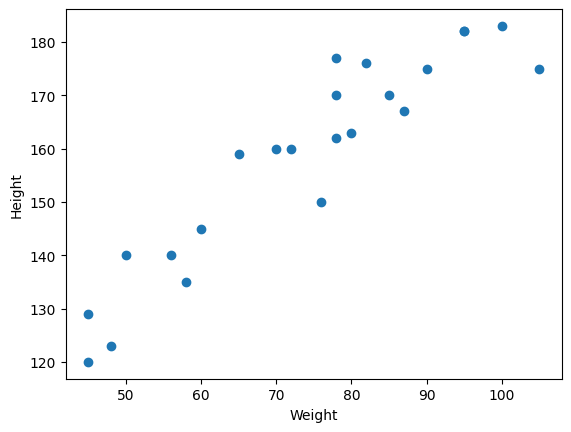

In [7]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()

##### It show a linear relationship 

In [8]:
## correlation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


* The correlation b/w `Weight` and `Height` is highly `Positively correlated`

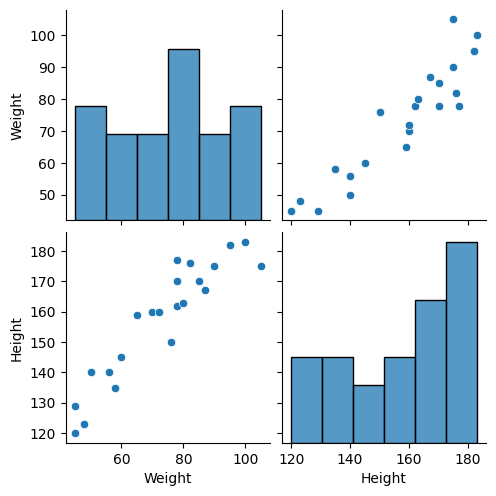

In [10]:
### we use seaborn for visulation of this correlation
import seaborn as sns 
sns.pairplot(df)

<Axes: >

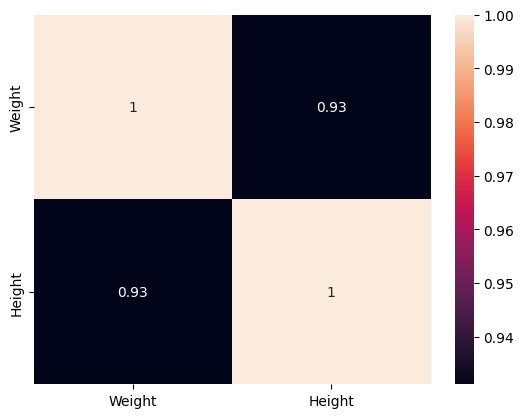

In [12]:
sns.heatmap(df.corr(),annot=True)

* In this data `Simple Linear Regression` is going to work well because the data follow a linear Relationship

### Depandant and Indepandant Feautres 

* Always remember that your **Indepandant features** should be in the form of `DataFrame` or `Two-Dimentional Array`
* If it can be in the form of 1-dimentional array or Series it gives you an Error.

In [ ]:
X = df[['Weight']]  ### indepandant feature should be dataframe or 2-Dimentional array
y = df['Height']   ## Depandant feature must be a Series or 1-Dimentional array

In [15]:
X

,Weight
0,45
1,58
2,48
3,60
4,70
5,78
6,80
7,90
8,95
9,78


In [ ]:
np.array(df['Weight']).reshape(-1,1)   ## This is 2-Dimentional array

array([[ 45],
       [ 58],
       [ 48],
       [ 60],
       [ 70],
       [ 78],
       [ 80],
       [ 90],
       [ 95],
       [ 78],
       [ 82],
       [ 95],
       [105],
       [100],
       [ 85],
       [ 78],
       [ 50],
       [ 65],
       [ 76],
       [ 87],
       [ 45],
       [ 56],
       [ 72]])

In [25]:
y.shape

(23,)

In [20]:
## if we check 2 dimentional array shape 
np.array(df['Weight']).reshape(-1,1) .shape

(23, 1)

* It has `23` Rows and `1` column

In [ ]:
X.shape   ## X is a DataFrame of Indepandant feature

(23, 1)

* This show that the `2-Dimentional array` and `DataFrame` has same shape

In [ ]:
df['Weight'].shape   ## It show that series has only 23 rows

(23,)

In [23]:
X_series = df['Weight']

### **Train Test Split**

In [26]:
from sklearn.model_selection import train_test_split


In [28]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.25,random_state=42)

In [ ]:
X_train.shape

(17, 1)

In [30]:
X_test.shape

(6, 1)

In [31]:
y_train.shape,y_test.shape

((17,), (6,))

## **Standardization**

* It convert each value with `mean =0` and `std = 1`

* `Z-Score` = (xi - mean(x))/ std(x) ---->  It scale all the values in same unit 

* For `Standarization` we also use `Library`

In [32]:
from sklearn.preprocessing import StandardScaler

In [33]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

In [39]:
X_train

array([[-0.87662801],
       [ 1.66773133],
       [ 0.33497168],
       [-1.48242785],
       [ 1.36483141],
       [-1.6641678 ],
       [-0.75546804],
       [-0.1496682 ],
       [ 0.21381171],
       [-1.36126788],
       [-0.99778797],
       [-0.02850823],
       [ 1.06193149],
       [ 0.57729161],
       [ 0.75903157],
       [ 0.88019153],
       [ 0.45613165]])

* What ever data i have in my `X_train` I am going to use the same mean and standard deviation for Standardizing the `X_test ` also 

* If i apply scaler.fit_transform(X_test) then it calculate the mean and std of X_test then scaled the values using this mean and std which i don't want 

In [40]:
## For test data we use only transform instead of fit_transform because we want to use the same mean and std of train data
X_test = scaler.transform(X_test)

In [41]:
X_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

## Apply Simple Linear Regression

In [42]:
from sklearn.linear_model import LinearRegression

In [43]:
regression = LinearRegression()

* n_jobs =Represent the number of Processor in your system you want to use for training

In [45]:
# regression.fit(X_series,y)  it will raise an error because it can't accept Series

In [46]:
regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [48]:
## If i want to use all the processor for trianing 
regression = LinearRegression(n_jobs=-1)   ## using all the processor 
regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


* We know that we have two very important parameter which are `Intercept` and `Coefficient/Slope`

In [51]:
## in eqtn   y=mx + c  this is value of m

print('Coefficient of Variable: ',regression.coef_ )  ## This is the slope / Coefficient mean 1 unit ch

Coefficient of Variable:  [17.2982057]


* This slope value mean `1` `unit` movement change in `Weight` can change `17.2982057` unit movement in `Height`

In [52]:
## Intercept or value of c in equation y=mx+c 

print('Intercept of Variable: ',regression.intercept_ ) 

Intercept of Variable:  156.47058823529412


## To Plot the `Best Fit Line`

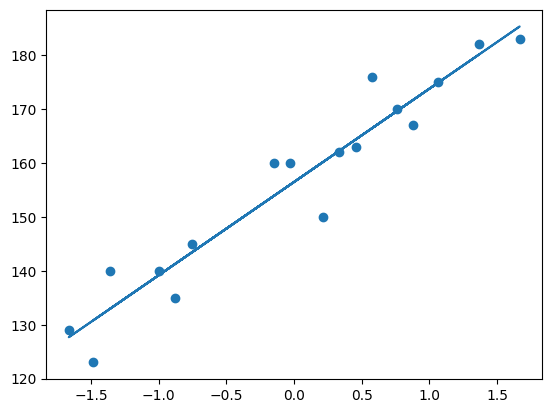

In [56]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train))

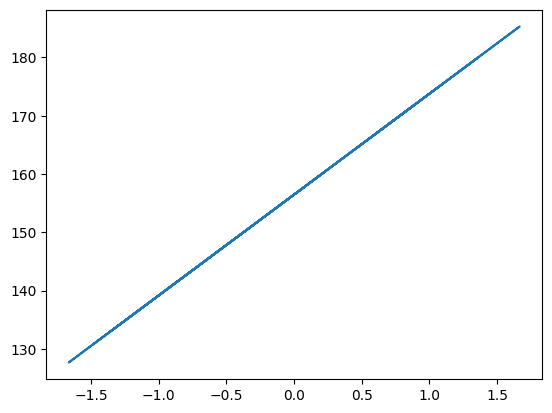

### **Prediction on Test Data**

1. Predicted height Output = intercept + coefficient * weights
2. y_pred_test = `156.47 + 17.29 x weights`

In [57]:
y_pred = regression.predict(X_test)

## performance Metrics

In [58]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [59]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)

print('mean_squared_error: ',mse)
print('mean_absolute_error: ',mae)
print('root_mean_squared_error: ',rmse)

mean_squared_error:  114.84069295228699
mean_absolute_error:  9.66512588679501
root_mean_squared_error:  10.716374991212605


## R-Square 
`Formula:` **R^2 = 1- SSR/SST**
* `R-Square` is also called `Coefficient of Determination`
1. `SSR: ` Sum of Square Residual
2. `SST:` Sum of Square of Total

In [60]:
from sklearn.metrics import r2_score

In [61]:
score = r2_score(y_test,y_pred)

In [ ]:
print('Accuracy of Our Model is this ')
print('R-Square Score is :',score)

Accuracy of Our Model is this 
R-Square Score is : 0.7360826717981276


## Adjusted R^2
`Formula :` 1-[(1-R^2)*(n-1)/(n-k-1)]
* Where


1. `n: ` Number of Observation or Data Points
2. `k:`  Number of predictor variables

In [66]:
# display the adjusted R-Squared
Accuracy = 1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

In [67]:
Accuracy

0.6701033397476595

## **Linear Regression using OLS** (Ordinary Least Squared) method

In [71]:
# pip install statsmodels


In [72]:
import statsmodels.api as sm

In [74]:
model = sm.OLS(y_train,X_train).fit()

In [77]:
model.predict(X_test)

array([  5.79440897,   5.79440897, -28.78711691,  23.60913442,
        -7.82861638,  34.08838469])

In [76]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Mon, 16 Feb 2026   Prob (F-statistic):                       0.664
Time:                        23:23:32   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            17.2982     39.138      0.442      0.664     -65.671     100.267
==============================================================================
Omnibus:                        0.135   Durbin-Watson:                   0.002
Prob(Omnibus):                  0.935   Jarque-Bera (JB):                0.203
Skew:                          -0.166   Prob(JB):                        0.904
Kurtosis:                       2.581   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""